# Parametric PINN Training (02 layout)

This notebook reuses the structure of **02_pinn_train.ipynb** but implements the
parametric/`ParamBC` logic from the dedicated parametric notebook.  

## Setup

In [1]:
import sys
from pathlib import Path
from dataclasses import dataclass
import json
import time
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import importlib

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "src").exists():
    raise RuntimeError("Could not find project root containing /src")
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))


import src.pinn
from src.utils import set_seed, get_device
from src.data import load_manifest_rows, load_case_manifest_row, ParamPINNBatch
from src.pinn import MLP, LeftBoundaryAnsatzMLP, LossWeights
from src.train import train_adam, train_lbfgs, compute_losses_eval

set_seed(42)
device = get_device()
print(f"Project root: {ROOT}")
print(f"Device: {device}")

MU_TIME_SAMPLES = 15

RUN_ID = datetime.now(timezone.utc).strftime("%Y_%m_%d_%H%M")
OUTDIR = ROOT / "outputs" / "parametric" / RUN_ID
OUTDIR.mkdir(parents=True, exist_ok=True)
print(f"RUN_ID: {RUN_ID}")
print(f"OUTDIR: {OUTDIR}")


Project root: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN
Device: cpu
RUN_ID: 2026_03_17_1010
OUTDIR: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\outputs\parametric\2026_03_17_1010


## Data Loading and Case Split

In [2]:
manifest = ROOT / "data" / "manifest.csv"
rows = load_manifest_rows(manifest)
if len(rows) < 2:
    raise RuntimeError("Need at least two cases for train/held-out split.")

# deterministic split; keep final 20% as held-out
rows_sorted = sorted(rows, key=lambda r: r["case_id"])
n_val_cases = max(1, int(round(0.2 * len(rows_sorted))))
val_rows = rows_sorted[-n_val_cases:]
train_rows = rows_sorted[:-n_val_cases]

if len(train_rows) == 0:
    raise RuntimeError("Split produced no training cases.")

print("Train cases:", [r["case_id"] for r in train_rows])
print("Held-out cases:", [r["case_id"] for r in val_rows])

Train cases: ['const_10000', 'const_10000_Tleft_280', 'const_10000_Tleft_300', 'const_10000_Tleft_310', 'const_12000', 'const_14000', 'const_15000', 'const_20000', 'const_5000', 'const_6000', 'offset_sine_1', 'sine_A10000_T100', 'sine_A10000_T50', 'sine_A12500_T125', 'sine_A12500_T25', 'sine_A12500_T75', 'sine_A5000_T100']
Held-out cases: ['sine_A5000_T50', 'sine_A7500_T125', 'sine_A7500_T25', 'sine_A7500_T75']


## Data Preprocessing and Parametric Batch

In [3]:
def compute_mu_stats(cases):
    eps = 1e-8
    all_mu = np.array([c["mu_raw"] for c in cases])
    mu_min = all_mu.min(axis=0)
    mu_max = all_mu.max(axis=0)
    return {
        "mu_min": mu_min,
        "mu_max": mu_max,
        "eps": eps,
    }


def normalise_mu(mu_raw, mu_stats):
    eps = mu_stats["eps"]
    mu_min = mu_stats["mu_min"]
    mu_max = mu_stats["mu_max"]
    return 2.0 * (mu_raw - mu_min) / (mu_max - mu_min + eps) - 1.0


def _load_case_with_mu(row: dict) -> dict:
    c = load_case_manifest_row(row, root=ROOT)

    # Conditioning uses only the informative right-boundary history.
    tau = c["nondim"]["tau"]
    theta = c["nondim"]["theta"]

    tau_max = tau.max()
    tau_samples = np.linspace(0, tau_max, MU_TIME_SAMPLES)
    theta_series_1 = np.interp(tau_samples, tau, theta[-1, :]).astype(np.float32)
    dtheta_dtau_1 = np.gradient(theta_series_1, tau_samples).astype(np.float32)

    mu_right_raw = np.concatenate([theta_series_1, dtheta_dtau_1]).astype(np.float32)

    c["mu_raw"] = mu_right_raw
    c["mu"] = mu_right_raw  # Will be normalized later.
    return c


train_cases = [_load_case_with_mu(r) for r in train_rows]
val_cases = [_load_case_with_mu(r) for r in val_rows]

mu_stats = compute_mu_stats(train_cases)
for c in (train_cases + val_cases):
    c["mu"] = normalise_mu(c["mu_raw"], mu_stats)

print(f"Loaded {len(train_cases)} train cases and {len(val_cases)} held-out cases.")
print("mu_stats min:", mu_stats["mu_min"][:5], "...")
print("mu_stats max:", mu_stats["mu_max"][:5], "...")

if train_cases:
    print("Example mu_right:", train_cases[0]["mu"][:5], "...")

all_mu = np.stack([c["mu"] for c in (train_cases + val_cases)], axis=0)
print("mu_vector mins:", all_mu.min(axis=0)[:5], "...")
print("mu_vector maxs:", all_mu.max(axis=0)[:5], "...")


Loaded 17 train cases and 4 held-out cases.
mu_stats min: [ 0.         -0.43433356 -0.912814   -0.9417071  -0.924139  ] ...
mu_stats max: [ 0.         -0.04965065 -0.13892409 -0.25023594 -0.3739256 ] ...
Example mu_right: [-1.         -0.5984565   0.05468321 -0.05479908 -0.19062448] ...
mu_vector mins: [-1.        -1.        -1.0000143 -1.0000017 -1.       ] ...
mu_vector maxs: [-1.         1.0000043  1.0000007  1.0000069  1.       ] ...


In [4]:
# Check boundary traces differ
for c in train_cases[:3]:  # check first 3
    print(f"Case {c['case_id']}: mu_raw[:5] = {c['mu_raw'][:5]}")
print("...")

Case const_10000: mu_raw[:5] = [ 0.         -0.3571001  -0.50470966 -0.6149175  -0.70147437]
Case const_10000_Tleft_280: mu_raw[:5] = [ 0.         -0.3571001  -0.50470966 -0.6149175  -0.7014753 ]
Case const_10000_Tleft_300: mu_raw[:5] = [ 0.         -0.3571001  -0.50470966 -0.6149175  -0.7014753 ]
...


## Create Batch

In [5]:
# collocation points (same geometry for train/val)
rng = np.random.default_rng(42)
n_r = 1500

# determine nondimensional tau range across training cases (use for sampling)
tau_max = max(c["nondim"]["tau"].max() for c in train_cases)
xi_r = rng.uniform(0.0, 1.0, size=(n_r, 1)).astype(np.float32)
tau_r = rng.uniform(0.0, float(tau_max), size=(n_r, 1)).astype(np.float32)
xi_r_val = rng.uniform(0.0, 1.0, size=(n_r // 5, 1)).astype(np.float32)
tau_r_val = rng.uniform(0.0, float(tau_max), size=(n_r // 5, 1)).astype(np.float32)

# assemble training batch using param cases
xi_data_train = []
tau_data_train = []
theta_data_train = []
mu_data_train = []

for c in train_cases:
    xi = c["nondim"]["xi"]
    tau = c["nondim"]["tau"]
    theta = c["nondim"]["theta"]

    xi_grid, tau_grid = np.meshgrid(xi, tau, indexing="ij")
    subsample_k = 2
    xi_grid = xi_grid[::subsample_k, ::subsample_k]
    tau_grid = tau_grid[::subsample_k, ::subsample_k]
    theta = theta[::subsample_k, ::subsample_k]
    interior_mask = (xi_grid > 0.0) & (xi_grid < 1.0)
    xi_data_train.append(xi_grid[interior_mask].reshape(-1, 1))
    tau_data_train.append(tau_grid[interior_mask].reshape(-1, 1))
    theta_data_train.append(theta[interior_mask].reshape(-1, 1))
    mu_data_train.append(np.repeat(c["mu"].reshape(1, -1), int(interior_mask.sum()), axis=0))

xi_data_train = np.vstack(xi_data_train).astype(np.float32)
tau_data_train = np.vstack(tau_data_train).astype(np.float32)
theta_data_train = np.vstack(theta_data_train).astype(np.float32)
mu_data_train = np.vstack(mu_data_train).astype(np.float32)

# same for validation
xi_data_val = []
tau_data_val = []
theta_data_val = []
mu_data_val = []
for c in val_cases:
    xi = c["nondim"]["xi"]
    tau = c["nondim"]["tau"]
    theta = c["nondim"]["theta"]
    xi_grid, tau_grid = np.meshgrid(xi, tau, indexing="ij")
    subsample_k = 2
    xi_grid = xi_grid[::subsample_k, ::subsample_k]
    tau_grid = tau_grid[::subsample_k, ::subsample_k]
    theta = theta[::subsample_k, ::subsample_k]
    interior_mask = (xi_grid > 0.0) & (xi_grid < 1.0)
    xi_data_val.append(xi_grid[interior_mask].reshape(-1, 1))
    tau_data_val.append(tau_grid[interior_mask].reshape(-1, 1))
    theta_data_val.append(theta[interior_mask].reshape(-1, 1))
    mu_data_val.append(np.repeat(c["mu"].reshape(1, -1), int(interior_mask.sum()), axis=0))

xi_data_val = np.vstack(xi_data_val).astype(np.float32)
tau_data_val = np.vstack(tau_data_val).astype(np.float32)
theta_data_val = np.vstack(theta_data_val).astype(np.float32)
mu_data_val = np.vstack(mu_data_val).astype(np.float32)

torch_zero = lambda *shape: torch.zeros(shape, dtype=torch.float32, device=device)

# sample conditioning vectors for collocation / IC points from the matching split
rng_mu = np.random.default_rng(42)

def _sample_mu(case_list, n):
    idx = rng_mu.integers(0, len(case_list), size=n)
    return np.stack([case_list[i]["mu"] for i in idx], axis=0).astype(np.float32)

mu_r_train = _sample_mu(train_cases, n_r)
mu_r_val = _sample_mu(val_cases, n_r // 5)

# IC points
n_ic = 1000
xi_ic = rng.uniform(0.0, 1.0, size=(n_ic, 1)).astype(np.float32)
tau_ic = np.zeros((n_ic, 1), dtype=np.float32)
mu_ic = _sample_mu(train_cases, n_ic)
mu_ic_val = _sample_mu(val_cases, n_ic)
theta_ic = np.zeros((n_ic, 1), dtype=np.float32)

# BC points: left fixed Dirichlet at xi=0, right temperature consistency at xi=1
def _interp_theta_right_for_case(case, tau_query):
    tau_case = case["nondim"]["tau"].reshape(-1)
    theta_right = case["nondim"]["theta"][-1, :].reshape(-1)
    return np.interp(tau_query.flatten(), tau_case, theta_right).reshape(-1, 1).astype(np.float32)

n_bc = 1000
n_bc_left = n_bc // 2
n_bc_right = n_bc - n_bc_left

xi_bc_left = np.zeros((n_bc_left, 1), dtype=np.float32)
tau_bc_left = rng.uniform(0.0, float(tau_max), size=(n_bc_left, 1)).astype(np.float32)
case_idx_left = rng_mu.integers(0, len(train_cases), size=n_bc_left)
mu_bc_left = np.stack([train_cases[i]["mu"] for i in case_idx_left], axis=0)
theta_bc_left = np.zeros_like(xi_bc_left, dtype=np.float32)

xi_bc_right = np.ones((n_bc_right, 1), dtype=np.float32)
tau_bc_right = rng.uniform(0.0, float(tau_max), size=(n_bc_right, 1)).astype(np.float32)
case_idx_right = rng_mu.integers(0, len(train_cases), size=n_bc_right)
mu_bc_right = np.stack([train_cases[i]["mu"] for i in case_idx_right], axis=0)
theta_bc_right = np.vstack([
    _interp_theta_right_for_case(train_cases[i], tau_bc_right[j : j + 1])
    for j, i in enumerate(case_idx_right)
])

xi_bc = np.vstack([xi_bc_left, xi_bc_right])
tau_bc = np.vstack([tau_bc_left, tau_bc_right])
mu_bc = np.vstack([mu_bc_left, mu_bc_right])
theta_bc = np.vstack([theta_bc_left, theta_bc_right])

train_batch = ParamPINNBatch(
    xi_r=torch.tensor(xi_r, dtype=torch.float32, device=device),
    tau_r=torch.tensor(tau_r, dtype=torch.float32, device=device),
    mu_r=torch.tensor(mu_r_train, dtype=torch.float32, device=device),
    xi_ic=torch.tensor(xi_ic, dtype=torch.float32, device=device),
    tau_ic=torch.tensor(tau_ic, dtype=torch.float32, device=device),
    mu_ic=torch.tensor(mu_ic, dtype=torch.float32, device=device),
    theta_ic=torch.tensor(theta_ic, dtype=torch.float32, device=device),
    xi_bc=torch.tensor(xi_bc, dtype=torch.float32, device=device),
    tau_bc=torch.tensor(tau_bc, dtype=torch.float32, device=device),
    mu_bc=torch.tensor(mu_bc, dtype=torch.float32, device=device),
    theta_bc=torch.tensor(theta_bc, dtype=torch.float32, device=device),
    xi_data=torch.tensor(xi_data_train, dtype=torch.float32, device=device),
    tau_data=torch.tensor(tau_data_train, dtype=torch.float32, device=device),
    mu_data=torch.tensor(mu_data_train, dtype=torch.float32, device=device),
    theta_data=torch.tensor(theta_data_train, dtype=torch.float32, device=device),
)

# Validation batch: held-out conditioning and held-out right-boundary targets
case_idx_left_val = rng_mu.integers(0, len(val_cases), size=n_bc_left)
mu_bc_left_val = np.stack([val_cases[i]["mu"] for i in case_idx_left_val], axis=0)
theta_bc_left_val = np.zeros_like(xi_bc_left, dtype=np.float32)

case_idx_right_val = rng_mu.integers(0, len(val_cases), size=n_bc_right)
mu_bc_right_val = np.stack([val_cases[i]["mu"] for i in case_idx_right_val], axis=0)
theta_bc_right_val = np.vstack([
    _interp_theta_right_for_case(val_cases[i], tau_bc_right[j : j + 1])
    for j, i in enumerate(case_idx_right_val)
])

mu_bc_val = np.vstack([mu_bc_left_val, mu_bc_right_val])
theta_bc_val = np.vstack([theta_bc_left_val, theta_bc_right_val])

val_batch = ParamPINNBatch(
    xi_r=torch.tensor(xi_r_val, dtype=torch.float32, device=device),
    tau_r=torch.tensor(tau_r_val, dtype=torch.float32, device=device),
    mu_r=torch.tensor(mu_r_val, dtype=torch.float32, device=device),
    xi_ic=torch.tensor(xi_ic, dtype=torch.float32, device=device),
    tau_ic=torch.tensor(tau_ic, dtype=torch.float32, device=device),
    mu_ic=torch.tensor(mu_ic_val, dtype=torch.float32, device=device),
    theta_ic=torch.tensor(theta_ic, dtype=torch.float32, device=device),
    xi_bc=torch.tensor(xi_bc, dtype=torch.float32, device=device),
    tau_bc=torch.tensor(tau_bc, dtype=torch.float32, device=device),
    mu_bc=torch.tensor(mu_bc_val, dtype=torch.float32, device=device),
    theta_bc=torch.tensor(theta_bc_val, dtype=torch.float32, device=device),
    xi_data=torch.tensor(xi_data_val, dtype=torch.float32, device=device),
    tau_data=torch.tensor(tau_data_val, dtype=torch.float32, device=device),
    mu_data=torch.tensor(mu_data_val, dtype=torch.float32, device=device),
    theta_data=torch.tensor(theta_data_val, dtype=torch.float32, device=device),
)

print("Data loaded and split successfully (parametric temperature-conditioned path).")
print(f"mu_r shape: {train_batch.mu_r.shape}")


Data loaded and split successfully (parametric temperature-conditioned path).
mu_r shape: torch.Size([1500, 30])


## Training

In [6]:
# build and train two variants:
# 1. soft BC with separate left/right boundary weights
# 2. hard left-boundary ansatz theta(xi, tau, mu) = xi * N(xi, tau, mu)
weights = LossWeights(
    w_pde=1.0,
    w_ic=1.0,
    w_bc_left=5.0,
    w_bc_right=1.0,
    w_data=1.0,
)

N_DATA_BATCH = 5000
EVAL_EVERY = 800
IN_DIM = 2 + mu_data_train.shape[1]

print(f"Using device: {device}")
print(f"n_r (collocation points): {n_r}")
print(f"N_DATA_BATCH (data loss subsample): {N_DATA_BATCH}")
print(f"eval_every: {EVAL_EVERY}")
print(f"weights: {weights}")

variant_builders = {
    #"soft_bc": lambda: MLP(in_dim=IN_DIM, hidden=64, layers=3).to(device),
    "hard_left_bc": lambda: LeftBoundaryAnsatzMLP(in_dim=IN_DIM, hidden=64, layers=4).to(device),
}

training_results = {}

for variant_name, builder in variant_builders.items():
    print(f"\n=== Training variant: {variant_name} ===")
    variant_dir = OUTDIR / variant_name
    variant_dir.mkdir(parents=True, exist_ok=True)
    variant_model = builder()

    best_path = train_adam(
        variant_model,
        train_batch,
        weights,
        lr=1e-3,
        run_dir=variant_dir,
        val_batch=val_batch,
        print_every=100,
        eval_every=EVAL_EVERY,
        patience_evals=10,
        plateau_window=6,
        plateau_rel_tol=0.008,
        pde_guardrail_rel=0.05,
        data_batch_size=N_DATA_BATCH,
        case_id=f"{RUN_ID}_{variant_name}",
    )

    best_lbfgs_path = train_lbfgs(
        variant_model,
        train_batch,
        weights,
        max_iter=1000,
        run_dir=variant_dir,
        case_id=f"{RUN_ID}_{variant_name}",
        val_batch=val_batch,
    )

    ckpt = best_lbfgs_path if best_lbfgs_path is not None and best_lbfgs_path.exists() else best_path
    if ckpt is not None and ckpt.exists():
        state = torch.load(ckpt, map_location=device)
        variant_model.load_state_dict(state["state_dict"])
        variant_model.to(device)

    _, train_logs_final = compute_losses_eval(variant_model, train_batch, weights, create_graph=False)
    _, val_logs_final = compute_losses_eval(variant_model, val_batch, weights, create_graph=False)

    training_results[variant_name] = {
        "model": variant_model,
        "best_path": best_path,
        "best_lbfgs_path": best_lbfgs_path,
        "checkpoint": ckpt,
        "train_logs": train_logs_final,
        "val_logs": val_logs_final,
        "run_dir": variant_dir,
    }

print("\nTraining completed for all variants.")
summary_rows = []
for variant_name, result in training_results.items():
    summary_rows.append({
        "variant": variant_name,
        "train_bc_left_rmse": result["train_logs"].get("bc_left_rmse", np.nan),
        "train_bc_right_rmse": result["train_logs"].get("bc_right_rmse", np.nan),
        "val_bc_left_rmse": result["val_logs"].get("bc_left_rmse", np.nan),
        "val_bc_right_rmse": result["val_logs"].get("bc_right_rmse", np.nan),
        "val_data_mse": result["val_logs"].get("data", np.nan),
        "val_total": result["val_logs"].get("total", np.nan),
    })
summary_df = pd.DataFrame(summary_rows)
display(summary_df)

# Backward-compatible handles for downstream cells.
model = training_results["soft_bc"]["model"]
best_path = training_results["soft_bc"]["best_path"]
best_lbfgs_path = training_results["soft_bc"]["best_lbfgs_path"]


Using device: cpu
n_r (collocation points): 1500
N_DATA_BATCH (data loss subsample): 5000
eval_every: 500
weights: LossWeights(w_pde=1.0, w_ic=1.0, w_bc=None, w_bc_left=5.0, w_bc_right=1.0, w_data=1.0)

=== Training variant: hard_left_bc ===
Cunt
[Adam] step 1/20000 | total=1.5535e+00 (pde=7.05e-01, ic=9.79e-03, bcL=0.00e+00, bcR=6.72e-01, data=1.66e-01) | bc_rmse(L=0.00e+00, R=8.20e-01) | val_rmse=2.83e-01 | val_bc_rmse(L=0.00e+00, R=5.55e-01) | val_pde=3.76e-01 | grad=1.29e+01 | 0.1s
[Adam] step 100/20000 | total=1.4631e-01 (pde=1.96e-02, ic=2.17e-02, bcL=0.00e+00, bcR=8.43e-02, data=2.06e-02) | bc_rmse(L=0.00e+00, R=2.90e-01) | val_rmse=nan | val_bc_rmse(L=nan, R=nan) | val_pde=nan | grad=9.01e-02 | 12.2s
[Adam] step 200/20000 | total=1.1473e-01 (pde=8.99e-03, ic=1.47e-02, bcL=0.00e+00, bcR=7.33e-02, data=1.77e-02) | bc_rmse(L=0.00e+00, R=2.71e-01) | val_rmse=nan | val_bc_rmse(L=nan, R=nan) | val_pde=nan | grad=8.18e-02 | 23.8s
[Adam] step 300/20000 | total=9.1767e-02 (pde=1.91e-03,

KeyboardInterrupt: 

## Plot

In [ ]:
best_lbfgs_path

WindowsPath('c:/Users/wscm13/OneDrive - Loughborough University/Part C/IDP/Individual Project/PINN/outputs/parametric/2026_03_16_1550/soft_bc/2026_03_16_1550_soft_bc_best.pt')

In [ ]:
# Select a held-out case for plotting and compare both trained variants.
test_case = val_cases[0]
case_id = test_case["case_id"]
print(f"Plotting held-out comparison for case: {case_id}")

xi = test_case["nondim"]["xi"]
tau = test_case["nondim"]["tau"]
theta_true = test_case["nondim"]["theta"]
mu_case = test_case["mu"]

T_left = float(test_case["physical"]["T_ref"])
dT = float(test_case["physical"]["dT_ref"])

xi_grid, tau_grid = np.meshgrid(xi, tau, indexing="ij")
xi_flat = xi_grid.flatten()
tau_flat = tau_grid.flatten()
mu_flat = np.tile(mu_case, (xi_flat.size, 1))
X_pred = np.column_stack([xi_flat, tau_flat, mu_flat]).astype(np.float32)
X_pred_tensor = torch.tensor(X_pred, device=device)

predictions = {}
comparison_rows = []
interior_mask = (xi_grid > 0.0) & (xi_grid < 1.0)

for variant_name, result in training_results.items():
    variant_model = result["model"]
    variant_model.eval()
    with torch.no_grad():
        theta_pred_flat = variant_model(X_pred_tensor).cpu().numpy().flatten()
    theta_pred = theta_pred_flat.reshape(xi_grid.shape)
    T_pred = T_left + dT * theta_pred

    left_rmse = float(np.sqrt(np.mean((theta_pred[0, :] - theta_true[0, :]) ** 2)))
    right_rmse = float(np.sqrt(np.mean((theta_pred[-1, :] - theta_true[-1, :]) ** 2)))
    interior_rmse = float(np.sqrt(np.mean((theta_pred[interior_mask] - theta_true[interior_mask]) ** 2)))
    full_rmse = float(np.sqrt(np.mean((theta_pred - theta_true) ** 2)))
    left_max_abs = float(np.max(np.abs(theta_pred[0, :])))

    predictions[variant_name] = {
        "theta_pred": theta_pred,
        "T_pred": T_pred,
    }
    comparison_rows.append({
        "variant": variant_name,
        "left_rmse": left_rmse,
        "left_max_abs": left_max_abs,
        "right_rmse": right_rmse,
        "interior_rmse": interior_rmse,
        "full_rmse": full_rmse,
    })

T_true = T_left + dT * theta_true
comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)
print("Hard ansatz should drive left_max_abs toward machine-zero because theta = xi * N.")


Plotting held-out comparison for case: sine_A5000_T100


,variant,left_rmse,left_max_abs,right_rmse,interior_rmse,full_rmse
0,soft_bc,0.000899,0.001784,0.003950,0.001638,0.001702
1,hard_left_bc,0.000000,0.000000,0.002016,0.000859,0.000888


Hard ansatz should drive left_max_abs toward machine-zero because theta = xi * N.


Saved boundary profiles plot to: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\outputs\parametric\2026_03_16_1550\boundary_profiles_compare_sine_A5000_T100.png


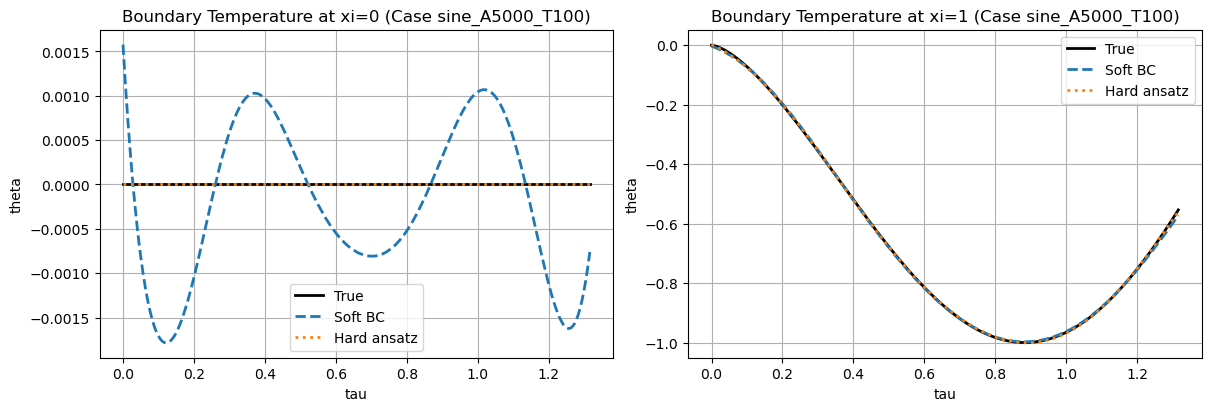

In [ ]:
# Plot boundary temperature profiles for both variants.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].plot(tau, theta_true[0, :], 'k-', label='True', linewidth=2)
axes[0].plot(tau, predictions['soft_bc']['theta_pred'][0, :], '--', label='Soft BC', linewidth=2)
axes[0].plot(tau, predictions['hard_left_bc']['theta_pred'][0, :], ':', label='Hard ansatz', linewidth=2)
axes[0].set_title(f'Boundary Temperature at xi=0 (Case {case_id})')
axes[0].set_xlabel('tau')
axes[0].set_ylabel('theta')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(tau, theta_true[-1, :], 'k-', label='True', linewidth=2)
axes[1].plot(tau, predictions['soft_bc']['theta_pred'][-1, :], '--', label='Soft BC', linewidth=2)
axes[1].plot(tau, predictions['hard_left_bc']['theta_pred'][-1, :], ':', label='Hard ansatz', linewidth=2)
axes[1].set_title(f'Boundary Temperature at xi=1 (Case {case_id})')
axes[1].set_xlabel('tau')
axes[1].set_ylabel('theta')
axes[1].legend()
axes[1].grid(True)

boundary_plot_path = OUTDIR / f"boundary_profiles_compare_{case_id}.png"
plt.savefig(boundary_plot_path, dpi=150, bbox_inches='tight')
print(f"Saved boundary profiles plot to: {boundary_plot_path}")
plt.show()


Saved temperature comparison plot to: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\outputs\parametric\2026_03_16_1550\temperature_comparison_sine_A5000_T100.png


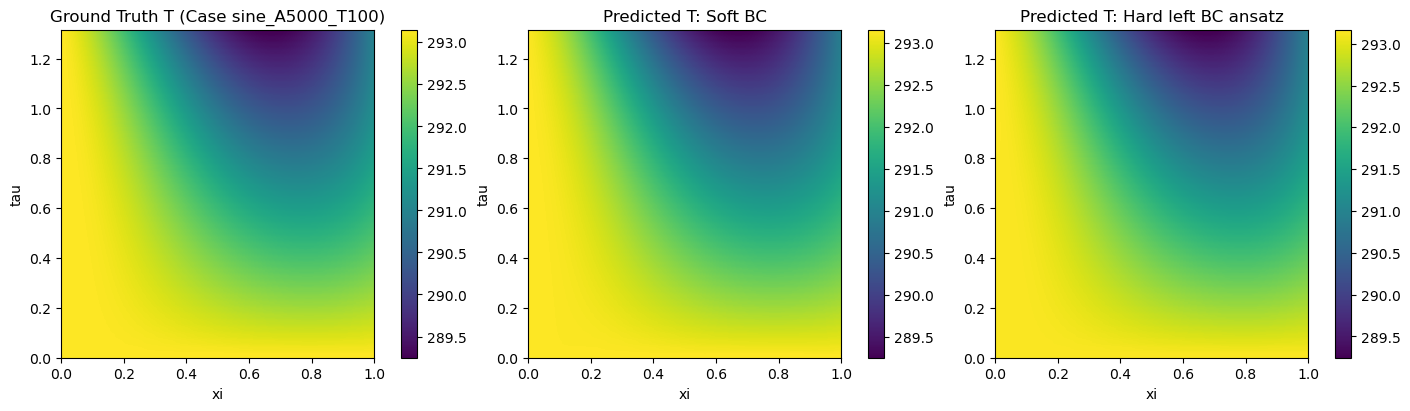

     variant  left_rmse  left_max_abs  right_rmse  interior_rmse  full_rmse
     soft_bc   0.000899      0.001784    0.003950       0.001638   0.001702
hard_left_bc   0.000000      0.000000    0.002016       0.000859   0.000888


In [ ]:
# Compare full-field predictions.
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

im0 = axes[0].imshow(T_true, aspect='auto', origin='lower', extent=[xi.min(), xi.max(), tau.min(), tau.max()])
axes[0].set_title(f'Ground Truth T (Case {case_id})')
axes[0].set_xlabel('xi')
axes[0].set_ylabel('tau')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(predictions['soft_bc']['T_pred'], aspect='auto', origin='lower', extent=[xi.min(), xi.max(), tau.min(), tau.max()])
axes[1].set_title('Predicted T: Soft BC')
axes[1].set_xlabel('xi')
axes[1].set_ylabel('tau')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(predictions['hard_left_bc']['T_pred'], aspect='auto', origin='lower', extent=[xi.min(), xi.max(), tau.min(), tau.max()])
axes[2].set_title('Predicted T: Hard left BC ansatz')
axes[2].set_xlabel('xi')
axes[2].set_ylabel('tau')
plt.colorbar(im2, ax=axes[2])

plot_path = OUTDIR / f"temperature_comparison_{case_id}.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"Saved temperature comparison plot to: {plot_path}")
plt.show()

print(comparison_df.to_string(index=False))


## Validation & Metrics

In [ ]:
# Validation summary for both variants.
metrics_path = OUTDIR / "validation_metrics_compare.txt"
with open(metrics_path, 'w', encoding='utf-8') as f:
    f.write("Validation Metrics Comparison\n")
    f.write("=============================\n")
    for variant_name, result in training_results.items():
        f.write(f"[{variant_name}]\n")
        for k, v in result["val_logs"].items():
            f.write(f"{k}: {v:.6e}\n")
        f.write("\n")
    f.write("Case-level comparison\n")
    f.write("---------------------\n")
    f.write(comparison_df.to_string(index=False))
    f.write("\n")
print(f"Saved validation metrics to: {metrics_path}")

for variant_name, result in training_results.items():
    print(f"\nValidation logs for {variant_name}:")
    for k, v in result["val_logs"].items():
        print(f"  {k}: {v:.4e}")

print("\nCase-level held-out comparison:")
print(comparison_df.to_string(index=False))
print("\nInterpretation:")
print("- hard_left_bc guarantees theta(0, tau) = 0 by construction because xi=0 => theta=0 exactly")
print("- compare right_rmse and interior_rmse to judge whether the ansatz improves left BC without harming the rest of the field")


Saved validation metrics to: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\outputs\parametric\2026_03_16_1550\validation_metrics_compare.txt

Validation logs for soft_bc:
  total: 1.5109e-04
  pde: 8.0546e-05
  ic: 1.0519e-05
  bc: 5.4853e-05
  bc_left: 2.1028e-05
  bc_right: 3.3825e-05
  bc_left_raw: 4.2056e-06
  bc_right_raw: 3.3825e-05
  bc_flux_legacy: 0.0000e+00
  bc_left_rmse: 2.0507e-03
  bc_right_rmse: 5.8159e-03
  bc_monitor: 0.0000e+00
  data: 5.1732e-06
  smooth: 0.0000e+00

Validation logs for hard_left_bc:
  total: 7.6325e-05
  pde: 4.8804e-05
  ic: 1.6360e-05
  bc: 9.3350e-06
  bc_left: 0.0000e+00
  bc_right: 9.3350e-06
  bc_left_raw: 0.0000e+00
  bc_right_raw: 9.3350e-06
  bc_flux_legacy: 0.0000e+00
  bc_left_rmse: 0.0000e+00
  bc_right_rmse: 3.0553e-03
  bc_monitor: 0.0000e+00
  data: 1.8256e-06
  smooth: 0.0000e+00

Case-level held-out comparison:
     variant  left_rmse  left_max_abs  right_rmse  interior_rmse  full_rmse
     so

## Upload and update

In [ ]:
from src.experiment_logging import append_arch_search_result, compare_arch_to_best, ensure_arch_search_csv, load_best_arch_result
from sklearn.model_selection import train_test_split
import math
import subprocess

In [ ]:
# Architecture experiment logger
results_csv = ROOT / "results" / "arch_search.csv"
ensure_arch_search_csv(str(results_csv))
baseline_best = load_best_arch_result(str(results_csv), metric="val_rmse_data")

def _safe_git_commit() -> str:
    try:
        out = subprocess.run(
            ["git", "rev-parse", "--short", "HEAD"],
            cwd=ROOT,
            capture_output=True,
            text=True,
            check=True,
        )
        return out.stdout.strip()
    except Exception:
        return ""

def _first_linear(module):
    for m in module.modules():
        if isinstance(m, torch.nn.Linear):
            return m
    return None

def _activation_name(module):
    for m in module.modules():
        if isinstance(m, (torch.nn.Tanh, torch.nn.ReLU, torch.nn.GELU, torch.nn.Sigmoid, torch.nn.SiLU, torch.nn.ELU, torch.nn.LeakyReLU)):
            return m.__class__.__name__.lower()
    return "unknown"

first_linear = _first_linear(model)
n_neurons = int(first_linear.out_features) if first_linear is not None else None
n_linear = sum(1 for m in model.modules() if isinstance(m, torch.nn.Linear))
n_hidden_layers = max(n_linear - 1, 0)

adam_steps = int(globals().get("N_EPOCHS", globals().get("steps", 1000)))
lbfgs_iters = int(globals().get("max_iter", 500)) if "best_lbfgs_path" in globals() else 0
optimizer_name = "adam+lbfgs" if "best_lbfgs_path" in globals() else "adam"

current_result = {
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "git_commit": _safe_git_commit(),
    "seed": 42,
    "n_layers": n_hidden_layers,
    "n_neurons": n_neurons,
    "activation": _activation_name(model),
    "optimizer": optimizer_name,
    "epochs": adam_steps + lbfgs_iters,
    "lr": 1e-3,
    "n_colloc": int(globals().get("n_r", 50000)),
    "n_boundary": int(getattr(train_batch, "xi_bc", torch.empty(0, 1)).shape[0]),
    "n_initial": int(getattr(train_batch, "xi_ic", torch.empty(0, 1)).shape[0]),
    "n_data": int(getattr(train_batch, "xi_data", torch.empty(0, 1)).shape[0]),
    "loss_total": float(val_logs.get("total", math.nan)),
    "loss_pde": float(val_logs.get("pde", math.nan)),
    "loss_ic": float(val_logs.get("ic", math.nan)),
    "loss_bc": float(val_logs.get("bc", math.nan)),
    "loss_data": float(val_logs.get("data", math.nan)),
    "val_rmse_data": float(rmse),
    "val_pde_loss": float(val_logs.get("pde", math.nan)),
}

improved, reason = compare_arch_to_best(current_result, baseline_best)
append_arch_search_result(str(results_csv), current_result)

def _fmt(x):
    try:
        v = float(x)
        if math.isfinite(v):
            return f"{v:.6e}"
    except Exception:
        pass
    return "nan"

print()
print("Architecture comparison:")
if baseline_best is None:
    print("Baseline best metrics: none (first recorded run)")
else:
    print(
        "Baseline best metrics: "
        f"val_rmse_data={_fmt(baseline_best.get('val_rmse_data'))}, "
        f"val_pde_loss={_fmt(baseline_best.get('val_pde_loss'))}, "
        f"loss_total={_fmt(baseline_best.get('loss_total'))}"
    )

print(
    "Current metrics: "
    f"val_rmse_data={_fmt(current_result.get('val_rmse_data'))}, "
    f"val_pde_loss={_fmt(current_result.get('val_pde_loss'))}, "
    f"loss_total={_fmt(current_result.get('loss_total'))}"
)
print(("? IMPROVED: " if improved else "? NOT IMPROVED: ") + reason)
print(f"Logged run to {results_csv}")



NameError: name 'val_logs' is not defined

In [ ]:
log_path = Path(ROOT, "results", "experiment_log.csv")
if log_path.exists():
    log_df = pd.read_csv(log_path)
    display(log_df.tail(5))
else:
    print(f"No log found at {log_path}")

,experiment_id,date_time_utc,commit_hash,python_version,torch_version,cuda_available,device,random_seed,case_id,data_paths,...,final_total_loss,final_pde_loss,final_bc_loss,final_ic_loss,final_data_loss,final_grad_norm,l2_error_temperature,max_abs_error,relative_l2_error,r2_score
0,20260216T153205Z_const_5000_596ff96_19ff91,2026-02-16T15:32:05.004343+00:00,596ff96,3.10.9,1.12.1,False,cpu,42,const_5000,manifest=c:\Users\wscm13\OneDrive - Loughborou...,...,0.001084,0.000171,0.000001,0.000576,0.000336,NaN,NaN,NaN,NaN,NaN
1,20260216T161524Z_const_5000_775133c_437d6a,2026-02-16T16:15:24.247973+00:00,775133c,3.10.9,1.12.1,False,cpu,42,const_5000,manifest=c:\Users\wscm13\OneDrive - Loughborou...,...,0.002162,0.000349,0.000325,0.001451,0.000037,NaN,NaN,NaN,NaN,NaN
2,20260309T145841Z_sine_A10000_T50_unknown_7eaa2a,2026-03-09T14:58:41.916964+00:00,unknown,3.10.9,1.12.1,False,cpu,42,sine_A10000_T50,manifest=c:\Users\wscm13\OneDrive - Loughborou...,...,0.002085,0.001231,0.000432,0.000148,0.000275,NaN,NaN,NaN,NaN,NaN
3,20260309T145841Z_sine_A10000_T50_unknown_7eaa2a,2026-03-09T14:58:41.916964+00:00,unknown,3.10.9,1.12.1,False,cpu,42,sine_A10000_T50,manifest=c:\Users\wscm13\OneDrive - Loughborou...,...,0.002085,0.001231,0.000432,0.000148,0.000275,NaN,NaN,NaN,NaN,NaN
